# Day 2: Protein Mix

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
from cdk.analysis.cytosol import platereader as pr
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Initialize plotting
pr.plot_setup()

# Load the data

Provide a CSV file containing the data, and a platemap. This function returns both the data with the plate map mapped to it, and the platemap by itself, which is useful for certain tasks.

In [3]:
platemap_path = "../1-design/PURE Workshop 1 Worksheets - Tue - Platemap.tsv"
data_path = "../2-data/20250513-204155-pure-timecourse-gfp-workshop-day2-measure-biotek-cdk.txt"

data, platemap = pr.load_platereader_data(data_path, platemap_path)
platemap.head()

,Well,Sample #,Participant,Type,Name,NEB Sol B -Ribos,Workshop Protein Mix,NEB Ribosomes,NEB Sol A,NEB Sol B,RNAse Inh,DNA,H2O,plamGFP standard,Total Volume
0,A1,1,Viktoriia,Sample,PM Viktoriia,0,3,4.50,10,0.00,1.25,1.25,5.00,0,10
1,A3,2,Riku,Sample,PM Riku,0,3,4.50,10,0.00,1.25,1.25,5.00,0,10
2,A5,3,Parsa,Sample,PM Parsa,0,3,4.50,10,0.00,1.25,1.25,5.00,0,10
3,A7,4,Adriana,Sample,PM Adriana,0,3,4.50,10,0.00,1.25,1.25,5.00,0,10
4,A9,5,Hanqiao,Sample,PM Hanqiao,0,3,4.50,10,0.00,1.25,1.25,5.00,0,10


# Basic Plots

## Kinetics 
Kinetic time traces of every well on the plate

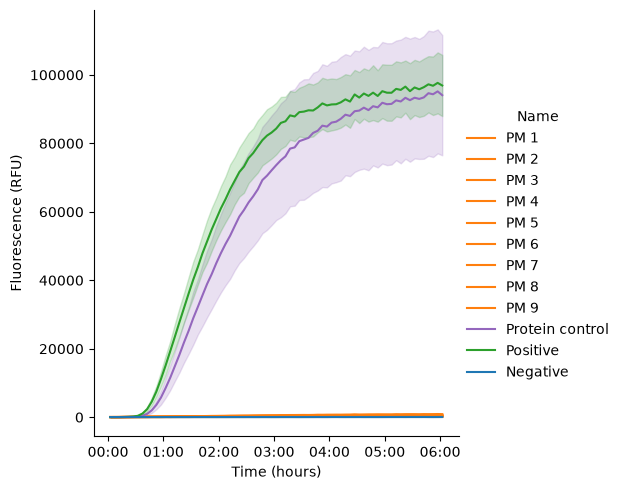

In [4]:
#| label: fig:day2-kinetics

exp_data = data[data["Type"] !="Standard"]

names_to_remove = ['NEB Small Molecule Control']

replace_dict = {'PM Viktoriia':'PM 1',
                'PM Riku':'PM 2',
                'PM Parsa':'PM 3',
                'PM Adriana':'PM 4',
                'PM Hanqiao':'PM 5',
                'PM Severine':'PM 6',
                'PM Jake':'PM 7',
                'PM Tyler':'PM 8',
                'PM bnext':'PM 9',
                'NEB Protein Control': 'Protein control',
                'NEB +DNA':'Positive',
                'NEB -DNA':'Negative'
               }


color_map = {'PM 1':'#ff7f0e',
                'PM 2':'#ff7f0e',
                'PM 3':'#ff7f0e',
                'PM 4':'#ff7f0e',
                'PM 5':'#ff7f0e',
                'PM 6':'#ff7f0e',
                'PM 7':'#ff7f0e',
                'PM 8':'#ff7f0e',
                'PM 9':'#ff7f0e',
                'Protein control':'#9467bd',
                'Positive':'#2ca02c',
                'Negative':'#1f77b4'
               }

data_drop = exp_data.drop(exp_data[exp_data['Name'].isin(names_to_remove)].index)
data_drop['Name'] = data_drop['Name'].replace(replace_dict)

# exp_data = data[data["Type"] != "Standard"]

pr.plot_curves(data_drop, palette=color_map);

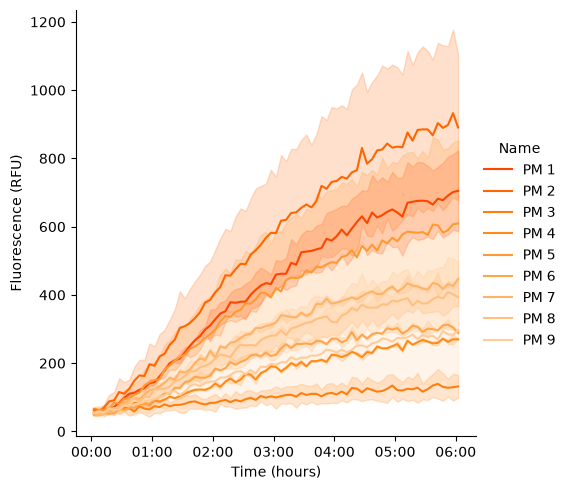

In [5]:
#| label: fig:day2-kinetics-participants

ppt_data = data[data["Type"] == "Sample"]

replace_dict = {'PM Viktoriia':'PM 1',
                'PM Riku':'PM 2',
                'PM Parsa':'PM 3',
                'PM Adriana':'PM 4',
                'PM Hanqiao':'PM 5',
                'PM Severine':'PM 6',
                'PM Jake':'PM 7',
                'PM Tyler':'PM 8',
                'PM bnext':'PM 9',
               }

orange_color_map = {'PM 1':'#ff4500',
                     'PM 2':'#ff6600',
                     'PM 3':'#ff7f0e',
                     'PM 4':'#ff8c1a',
                     'PM 5':'#ff9933',
                     'PM 6':'#ffa64d',
                     'PM 7':'#ffb366',
                     'PM 8':'#ffc080',
                     'PM 9':'#ffcc99'
                    }

ppt_data['Name'] = ppt_data['Name'].replace(replace_dict)

pr.plot_curves(ppt_data, palette=orange_color_map);

## Steady state
Bar graph of steady-state endpoint of each sample. Steady state is calculated as the maximum fluorescence value over a 3-sample rolling average on the data.

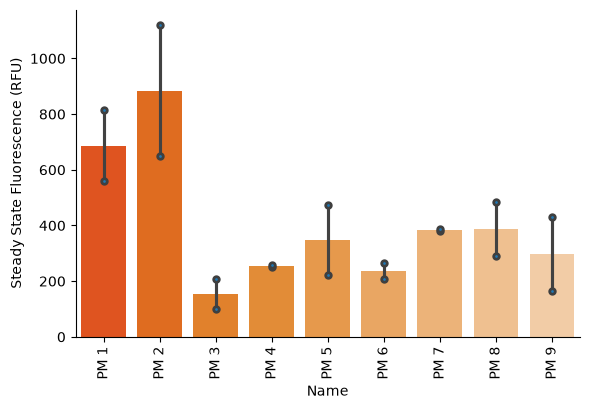

In [6]:
#| label: fig:day2-endpoint-participants

pr.plot_steadystate(ppt_data, palette=orange_color_map);

# Kinetics Analysis
These functions calculate key kinetic parameters of the time series.

PROVIDING AVERAGED KINETICS


(<seaborn.axisgrid.FacetGrid at 0x310667c50>,
                                               Velocity                        \
                                                   Time      Data         Max   
 Name                Read                                                       
 NEB +DNA            GFP-Gext 0 days 01:34:26.417182696  48877.26    44025.90   
 NEB -DNA            GFP-Gext 0 days 04:31:27.401688226     56.18       11.50   
 NEB Protein Control GFP-Gext 0 days 01:51:17.114221283  42502.79    34775.58   
 PM Adriana          GFP-Gext 0 days 02:06:51.274595217    134.23       42.05   
 PM Hanqiao          GFP-Gext 0 days 01:41:10.850735775    183.42      103.13   
 PM Jake             GFP-Gext 0 days 01:39:49.094103574    201.96       95.22   
 PM Parsa            GFP-Gext 0 days 02:17:29.207937283     80.83       19.21   
 PM Riku             GFP-Gext 0 days 01:57:23.886568420    465.41      170.92   
 PM Severine         GFP-Gext 0 days 01:34:52.370763448    124.

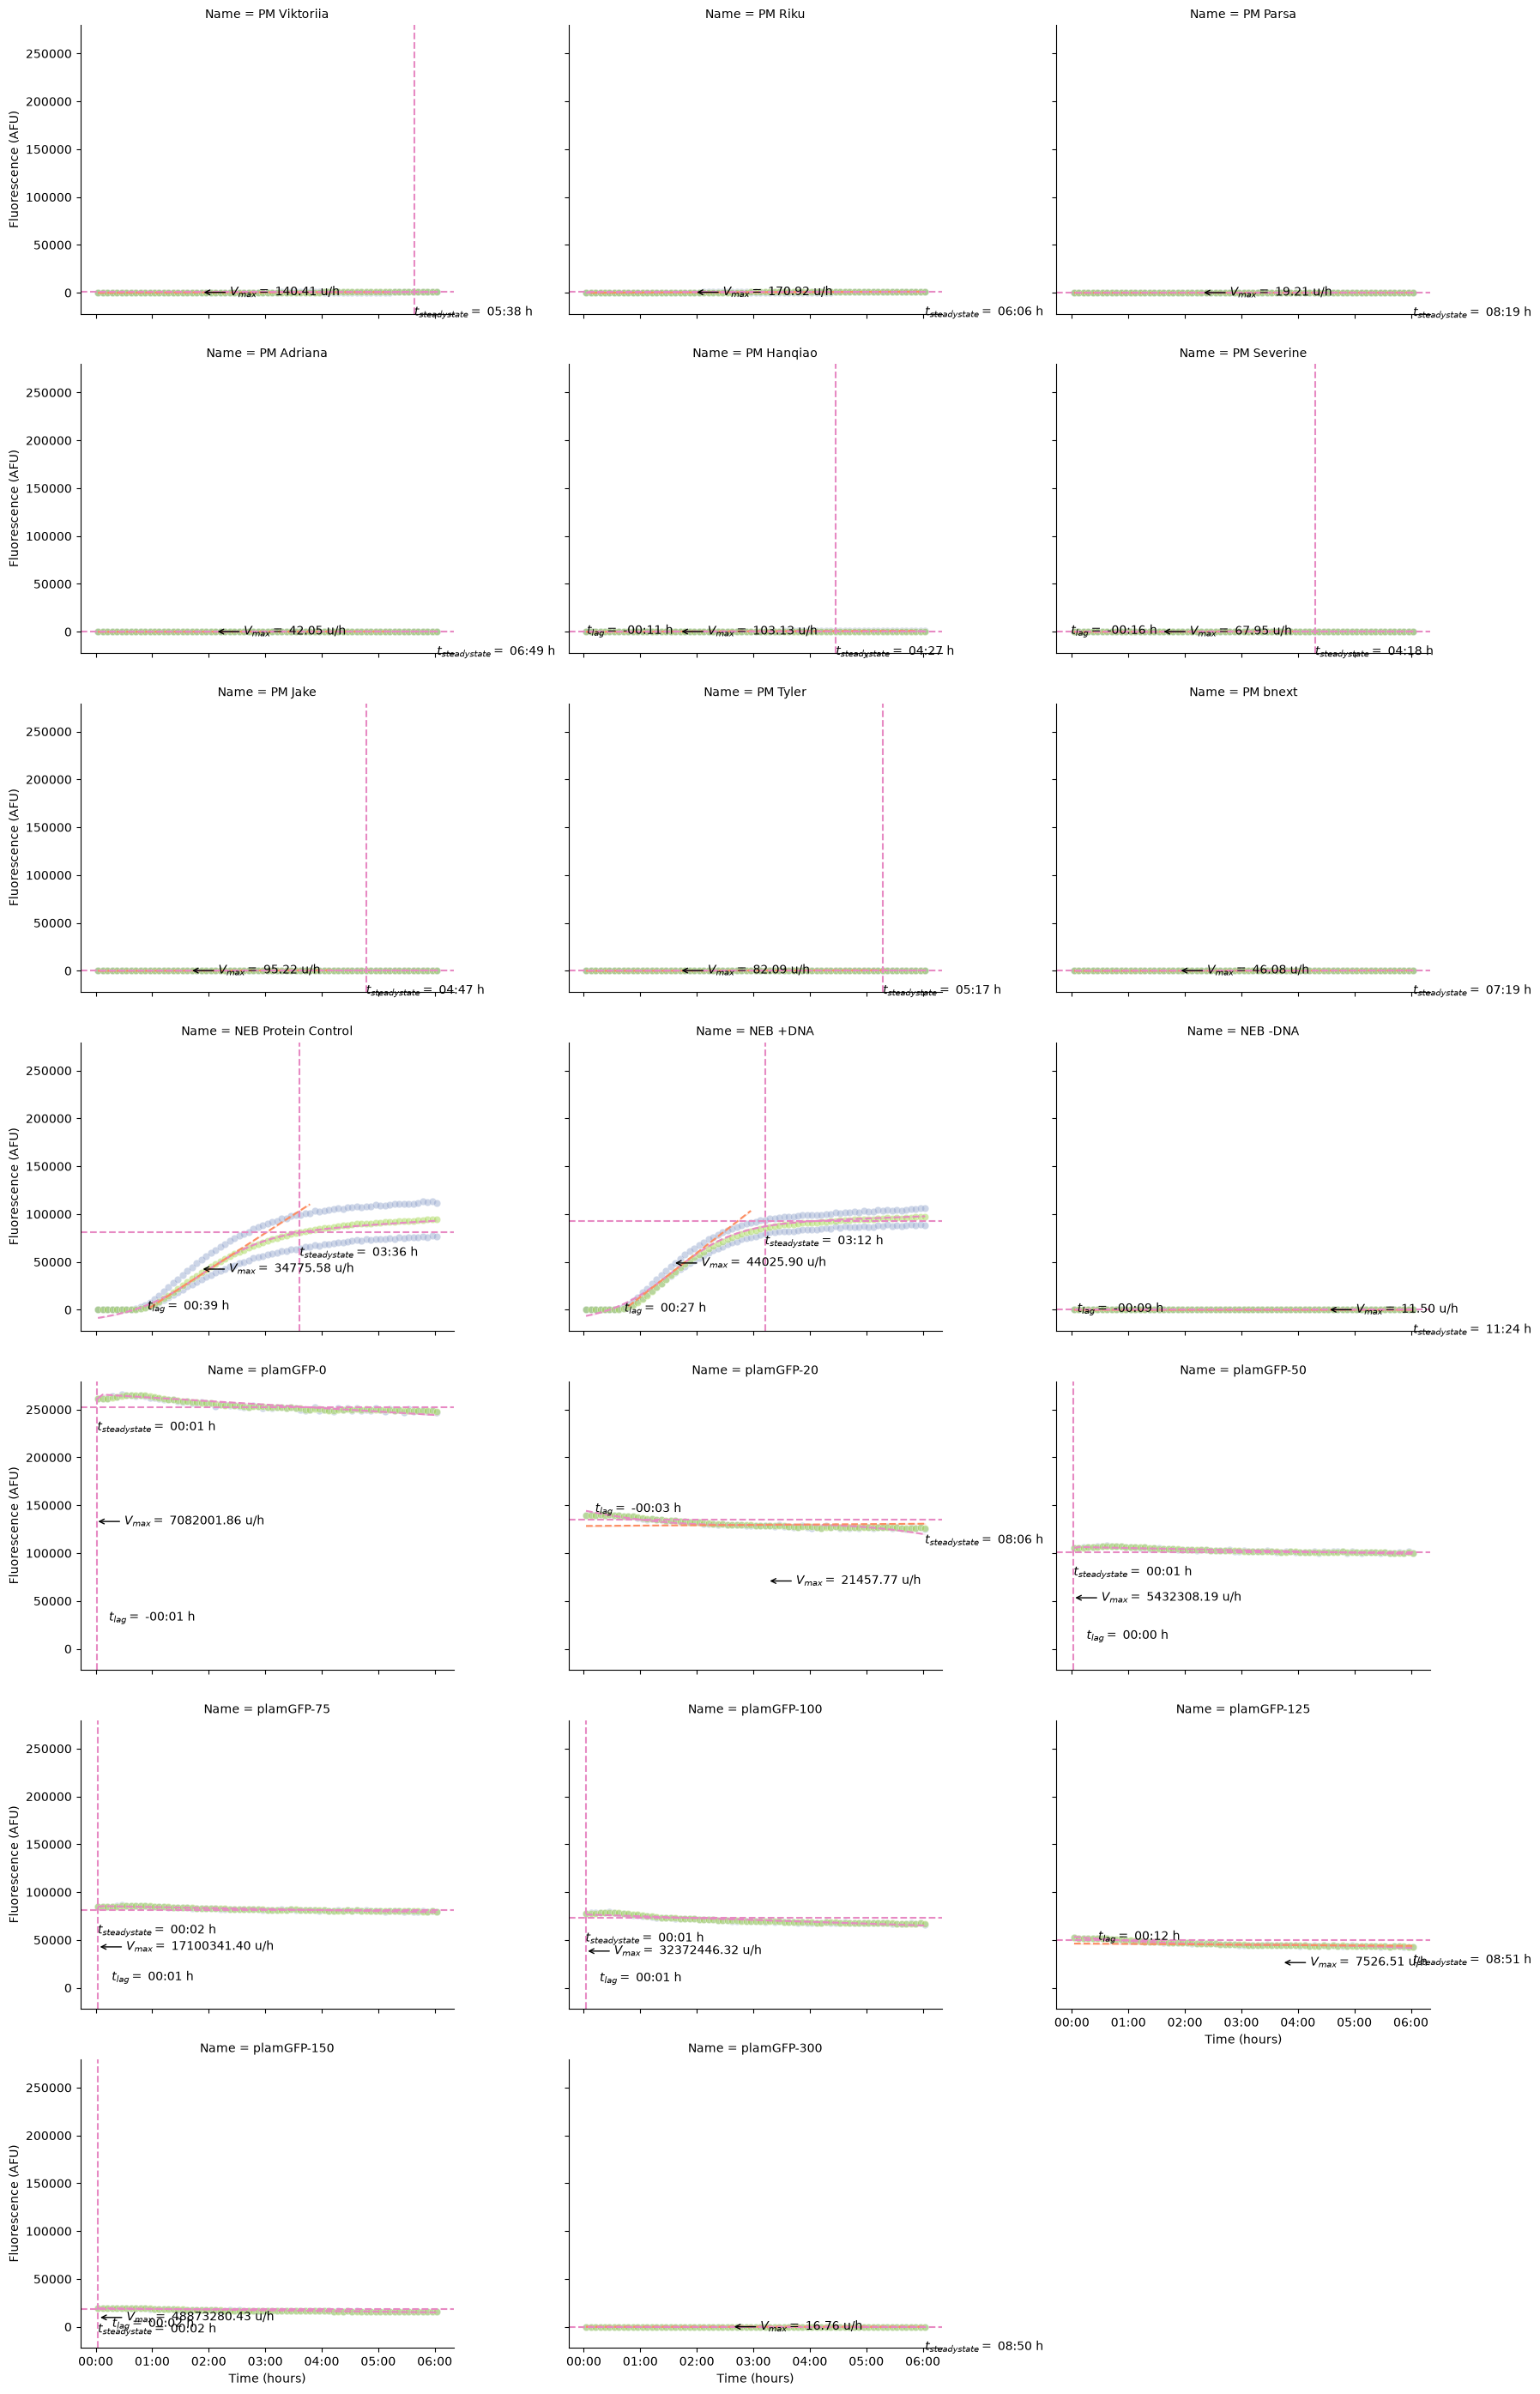

In [7]:
pr.plot_kinetics(data)

We can also calculate the kinetics and display the parameters as a table.

In [8]:
pr.kinetic_analysis(data)

Velocity            \
                                                       Time      Data   
Name                Read     Well                                       
PM Viktoriia        GFP-Gext A1   0 days 01:35:30.105488112    294.49   
PM Riku             GFP-Gext A3   0 days 01:45:22.622430276    588.65   
PM Parsa            GFP-Gext A5   0 days 01:58:01.327244707    109.94   
PM Adriana          GFP-Gext A7   0 days 02:11:38.558971860    132.44   
PM Hanqiao          GFP-Gext A9   0 days 01:37:19.439594572    249.57   
PM Severine         GFP-Gext A11  0 days 01:34:21.603957970    139.59   
PM Jake             GFP-Gext A13  0 days 01:42:13.574595438    199.88   
PM Tyler            GFP-Gext A15  0 days 01:48:10.036136952    254.33   
PM bnext            GFP-Gext A17  0 days 02:09:35.287702016     85.98   
NEB Protein Control GFP-Gext A19  0 days 01:54:57.395414437  28383.14   
NEB +DNA            GFP-Gext A21  0 days 01:38:13.923274984  44493.23   
NEB -DNA            GFP-Gext A23  0 days 03:00:34.803376452     32.00   
PM Viktoriia        GFP-Gext B1   0 days 02:08:52.432040410    428.48   
PM Riku             GFP-Gext B3   0 days 02:09:25.150706564    342.17   
PM Parsa            GFP-Gext B5   0 days 02:36:57.088629860     51.71   
PM Adriana          GFP-Gext B7   0 days 02:02:03.990218575    136.02   
PM Hanqiao          GFP-Gext B9   0 days 01:45:02.261876979    117.26   
PM Severine         GFP-Gext B11  0 days 01:35:23.137568926    108.95   
PM Jake             GFP-Gext B13  0 days 01:37:24.613611711    204.04   
PM Tyler            GFP-Gext B15  0 days 01:34:22.345397126    153.60   
PM bnext            GFP-Gext B17  0 days 01:36:54.525328236    226.36   
NEB Protein Control GFP-Gext B19  0 days 01:47:36.833028129  56622.43   
NEB +DNA            GFP-Gext B21  0 days 01:30:38.911090409  53261.28   
NEB -DNA            GFP-Gext B23            0 days 06:02:20     80.37   
plamGFP-0           GFP-Gext D1             0 days 00:00:00 133051.60   
plamGFP-20          GFP-Gext D3   0 days 03:14:59.717073174  70851.57   
plamGFP-50          GFP-Gext D5   0 days 00:00:59.411688552  53279.47   
plamGFP-75          GFP-Gext D7   0 days 00:01:58.295458574  42752.24   
plamGFP-100         GFP-Gext D9   0 days 00:01:46.760541484  38353.42   
plamGFP-125         GFP-Gext D11  0 days 03:42:46.616232956  26347.31   
plamGFP-150         GFP-Gext D13  0 days 00:02:18.460345891   9774.66   
plamGFP-300         GFP-Gext D15  0 days 02:37:06.115786168     70.90   

                                                                      Lag  \
                                          Max                        Time   
Name                Read     Well                                           
PM Viktoriia        GFP-Gext A1        119.68 -1 days +23:07:51.979954530   
PM Riku             GFP-Gext A3        230.79 -1 days +23:12:20.745064059   
PM Parsa            GFP-Gext A5         21.06 -1 days +20:44:48.225012314   
PM Adriana          GFP-Gext A7         40.43 -1 days +22:55:06.121862861   
PM Hanqiao          GFP-Gext A9        150.84 -1 days +23:58:03.123305440   
PM Severine         GFP-Gext A11        80.46 -1 days +23:50:16.129745816   
PM Jake             GFP-Gext A13        94.75 -1 days +23:35:39.470711662   
PM Tyler            GFP-Gext A15        89.20 -1 days +22:57:06.052222462   
PM bnext            GFP-Gext A17        20.33 -1 days +21:55:50.884582401   
NEB Protein Control GFP-Gext A19     26824.54   0 days 00:51:28.222383268   
NEB +DNA            GFP-Gext A21     40638.65   0 days 00:32:32.462648959   
NEB -DNA            GFP-Gext A23         9.89 -1 days +23:46:27.049552709   
PM Viktoriia        GFP-Gext B1        161.14 -1 days +23:29:19.747584442   
PM Riku             GFP-Gext B3        111.05 -1 days +23:04:32.487671921   
PM Parsa            GFP-Gext B5         17.35 -1 days +23:38:09.249121418   
PM Adriana          GFP-Gext B7         43.67 -1 days +22:55:11.070681759   
PM Hanqiao          GFP-Gext B9 